<h1>Train — InceptionNet v3</h1>

Trains and evaluates InceptionNet v3 using the tuned hyperparameters from `ARCH_HYPERPARAMS["inception_v3"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): NoordelikeWerke
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1692 | Val: 410 | Test: 405


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["inception_v3"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"InceptionNet v3: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

InceptionNet v3: micro batch = 16, accumulation steps = 1 (effective batch size ≈ 16, tuned value = 17)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with InceptionNet v3)
# ---------------------------------------------------------
model = models.inception_v3(weights=models.Inception_V3_Weights.IMAGENET1K_V1, aux_logits=True)

in_f = model.fc.in_features
model.fc = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

# The auxiliary classifier (used only during training, see run_epoch in
# wwtw_utils.py) also needs its output layer resized to our number of classes.
in_f_aux = model.AuxLogits.fc.in_features
model.AuxLogits.fc = nn.Linear(in_f_aux, num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the Bayesian-optimized step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[InceptionNet v3] Epoch   1/100 | LR: 1.43e-04 | train loss 1.4797 acc 0.515 | val loss 0.7625 acc 0.683 *


[InceptionNet v3] Epoch   2/100 | LR: 1.43e-04 | train loss 1.0558 acc 0.703 | val loss 0.6505 acc 0.768 *


[InceptionNet v3] Epoch   3/100 | LR: 1.43e-04 | train loss 0.8332 acc 0.760 | val loss 0.8384 acc 0.815


[InceptionNet v3] Epoch   4/100 | LR: 1.43e-04 | train loss 0.7864 acc 0.780 | val loss 0.6482 acc 0.800 *


[InceptionNet v3] Epoch   5/100 | LR: 1.43e-04 | train loss 0.7180 acc 0.798 | val loss 0.6875 acc 0.812


...

[InceptionNet v3] Epoch  13/100 | LR: 1.43e-04 | train loss 0.3484 acc 0.894 | val loss 0.5085 acc 0.841


[InceptionNet v3] Epoch  14/100 | LR: 1.43e-04 | train loss 0.3984 acc 0.902 | val loss 0.4754 acc 0.861


[InceptionNet v3] Epoch  15/100 | LR: 1.43e-04 | train loss 0.3979 acc 0.903 | val loss 0.5405 acc 0.832


[InceptionNet v3] Epoch  16/100 | LR: 1.43e-04 | train loss 0.3096 acc 0.909 | val loss 0.5775 acc 0.817


[InceptionNet v3] Epoch  17/100 | LR: 1.43e-04 | train loss 0.3567 acc 0.918 | val loss 0.9783 acc 0.832

[InceptionNet v3] No val loss improvement for 10 epochs — stopping early at epoch 17.

[InceptionNet v3] Restored best checkpoint (val loss = 0.4665)


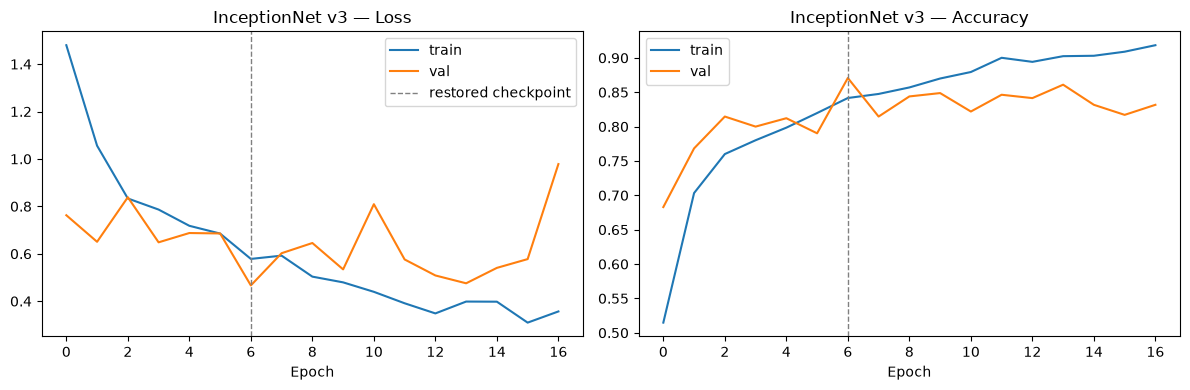

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "InceptionNet v3", is_inception=True,
    accum_steps=accum_steps,
)
plot_training_curves(history, "InceptionNet v3")

## Evaluate on the test set

[InceptionNet v3] Test accuracy: 0.753


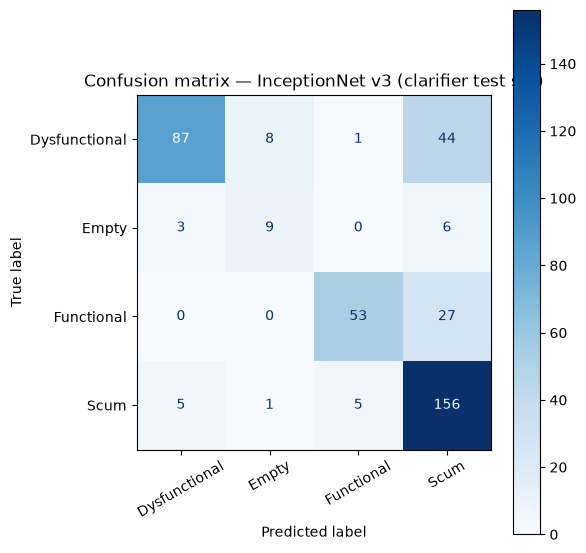

               precision    recall  f1-score   support

Dysfunctional      0.916     0.621     0.740       140
        Empty      0.500     0.500     0.500        18
   Functional      0.898     0.662     0.763        80
         Scum      0.670     0.934     0.780       167

     accuracy                          0.753       405
    macro avg      0.746     0.680     0.696       405
 weighted avg      0.792     0.753     0.750       405



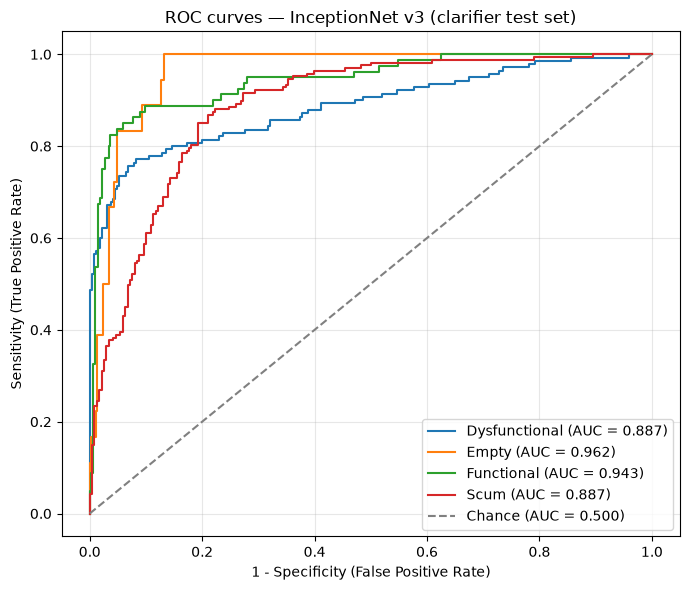

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.887
  Empty          : 0.962
  Functional     : 0.943
  Scum           : 0.887

Mean AUC (over 4/4 classes with test examples): 0.919


(np.float64(0.7530864197530864),
 {'Dysfunctional': 0.8867115902964959,
  'Empty': 0.96152741889176,
  'Functional': 0.9428076923076922,
  'Scum': 0.8868062194937856})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "InceptionNet v3", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("InceptionNet v3", "inception_v3")

Saved results to ../results/results_clarifier_inception_v3_NoordelikeWerke.pkl
Saved model weights to ../models/clarifier_inception_v3_cnn.pt
